# 01 — Basel Exposure Classes Before the Loan Data

## Start with the regulatory categories

The regulatory categories are defined before the synthetic loans are generated or classified. This keeps business products such as credit cards separate from the Basel classes used for capital.

An exposure class selects the risk-weight table or IRB risk function. Contractual commitment type selects the CCF. A wrong class can change the capital requirement even when the loan balance is correct.

### Names used in the classification

| Term | Simple meaning |
|---|---|
| Exposure class | a regulatory group with a defined capital treatment |
| Regulatory retail | qualifying exposures to individuals or SMEs managed as part of a granular pool |
| Transactor | a qualifying card or charge-card borrower who has repaid in full at each scheduled date for the previous 12 months |
| Defaulted exposure | a loan already meeting the project's default rule |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


## Exposure classes represented in the synthetic bank

The table states the class before showing any loan records. `CRE20` is the Basel chapter for the Standardised Approach. `CRE30–CRE32` cover IRB classification, risk functions and parameters.

In [2]:
exposure_classes = pd.DataFrame([
    ["Sovereign", "Central government or central bank", "Government bond or loan", "CRE20 / CRE30"],
    ["Bank", "Regulated bank or qualifying financial institution", "Interbank loan", "CRE20 / CRE30"],
    ["Corporate", "Company not meeting a more specific class", "Corporate term loan or revolver", "CRE20 / CRE30"],
    ["Corporate SME", "SME managed as a corporate exposure", "SME working-capital line", "CRE20 / CRE30"],
    ["Regulatory retail", "Eligible granular exposure managed as retail", "Personal loan", "CRE20 / CRE30"],
    ["Retail transactor", "Eligible retail borrower who regularly repays in full", "Qualifying credit card", "CRE20"],
    ["Revolving retail", "Retail balance that can be borrowed and repaid repeatedly", "Credit card revolver", "CRE20 / CRE30"],
    ["Residential real estate", "Eligible exposure secured by residential property", "Home mortgage", "CRE20 / CRE30"],
    ["Defaulted", "Exposure meeting the default definition", "Any product after default", "CRE20 / CRE31"],
    ["Other", "Exposure outside the selected classes", "Other lending", "CRE20"],
], columns=["Basel exposure class", "Simple definition", "Example product", "Basel reference"])
display(exposure_classes)

,Basel exposure class,Simple definition,Example product,Basel reference
0,Sovereign,Central government or central bank,Government bond or loan,CRE20 / CRE30
1,Bank,Regulated bank or qualifying financial institution,Interbank loan,CRE20 / CRE30
2,Corporate,Company not meeting a more specific class,Corporate term loan or revolver,CRE20 / CRE30
3,Corporate SME,SME managed as a corporate exposure,SME working-capital line,CRE20 / CRE30
4,Regulatory retail,Eligible granular exposure managed as retail,Personal loan,CRE20 / CRE30
5,Retail transactor,Eligible retail borrower who regularly repays in full,Qualifying credit card,CRE20
6,Revolving retail,Retail balance that can be borrowed and repaid repeatedly,Credit card revolver,CRE20 / CRE30
7,Residential real estate,Eligible exposure secured by residential property,Home mortgage,CRE20 / CRE30
8,Defaulted,Exposure meeting the default definition,Any product after default,CRE20 / CRE31
9,Other,Exposure outside the selected classes,Other lending,CRE20


## The order used to classify a loan

Classification is a sequence of questions. Default is checked first because it overrides performing treatment. The remaining questions identify the borrower and facility before a residual corporate or other class is used.

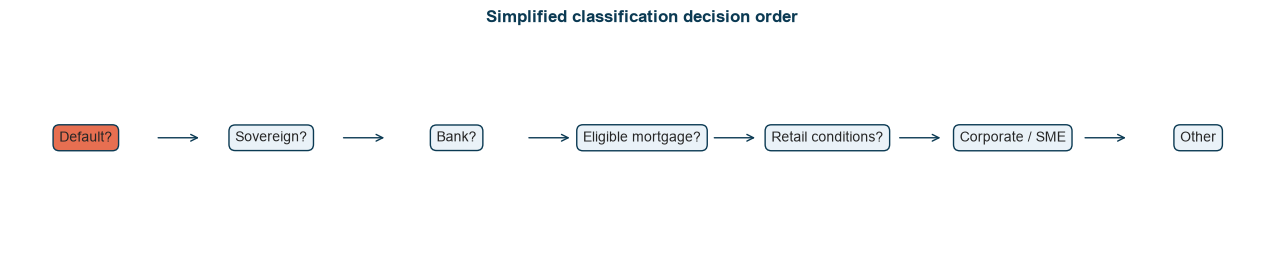

In [3]:
decision_steps = [
    "Default?", "Sovereign?", "Bank?", "Eligible mortgage?",
    "Retail conditions?", "Corporate / SME", "Other",
]
figure, axis = plt.subplots(figsize=(13, 2.8))
axis.axis("off")
x_positions = np.linspace(0.06, 0.94, len(decision_steps))
for index, (x, label) in enumerate(zip(x_positions, decision_steps)):
    colour = "#E76F51" if index == 0 else "#EAF2F8"
    axis.text(x, 0.52, label, ha="center", va="center", fontsize=10,
              bbox={"boxstyle": "round,pad=0.45", "facecolor": colour, "edgecolor": "#0B3A53"})
    if index < len(decision_steps) - 1:
        axis.annotate("", xy=(x_positions[index + 1] - 0.055, 0.52), xytext=(x + 0.055, 0.52),
                      arrowprops={"arrowstyle": "->", "color": "#0B3A53"})
axis.set_title("Simplified classification decision order", color="#0B3A53", weight="bold")
plt.tight_layout()
plt.show()

The diagram is deliberately a summary rather than a substitute for the detailed rules. Its implication is that a product label alone is not enough: a mortgage can fail property eligibility, a card can be a transactor or revolver, and any class can be replaced by defaulted treatment.

The same product can require different treatment when eligibility changes. A credit card may be a transactor or a revolving retail exposure. A mortgage uses real-estate treatment only when the property and underwriting conditions are satisfied. Default is an override because a defaulted loan no longer receives the performing treatment.

## Business products are not regulatory classes

The next table shows the intended starting mapping. The classification notebook later tests the actual fields on every row rather than relying only on this label.

In [4]:
starting_map = pd.DataFrame([
    ["Sovereign bond", "Sovereign"], ["Bank loan", "Bank"],
    ["Corporate revolver", "Corporate"], ["SME revolver", "Corporate SME"],
    ["Personal loan", "Regulatory retail"], ["Credit card paid in full", "Retail transactor"],
    ["Credit card revolver", "Revolving retail"], ["Mortgage", "Residential real estate"],
], columns=["Business product", "Expected Basel class"])
display(starting_map)

,Business product,Expected Basel class
0,Sovereign bond,Sovereign
1,Bank loan,Bank
2,Corporate revolver,Corporate
3,SME revolver,Corporate SME
4,Personal loan,Regulatory retail
5,Credit card paid in full,Retail transactor
6,Credit card revolver,Revolving retail
7,Mortgage,Residential real estate


This is an expectation rather than the final result. Borrower type, SME status, retail management, property eligibility, repayment behaviour and default status determine the final class stored on each loan.